In [1]:
from google.colab import files
uploaded = files.upload()

Saving Датасет invest_db.csv to Датасет invest_db (1).csv


# Раздел 1. Из домашнего задания №2

###**Настройка и предобработка данных:**
Также фиксирую `random_state` для воспроизводимости.
Я преобразую даты, удаляю пробелы и проверяю типы данных, также провожу проверку на наличие пропусков и дубликатов.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/Датасет invest_db.csv', sep=';')
print("Размер датафрейма:", df.shape)
display(df.head(3))
df.info()

df = pd.read_csv('/content/Датасет invest_db.csv', sep=';')
print("Размер датафрейма:", df.shape)
display(df.head(3))
df.info()

Размер датафрейма: (458370, 51)


,id,date,age,education_level_cd,marital_status_cd,children_cnt,monthly_income_amt,invest_utilization_dt,forts_flg,margin_status_flg,qualified_investor_flg,in_payment_rub_amt,out_payment_rub_amt,uncovered_position_amt,turnover_rus_bon_amt,turnover_rus_sec_amt,turnover_forts_amt,turnover_cur_amt,turnover_etf_amt,turnover_fnd_amt,turnover_opt_amt,turnover_ore_prc_amt,turnover_ore_sel_amt,turnover_tracking_amt,trade_order_rus_sec_cnt,trade_order_rus_bon_cnt,trade_order_forts_cnt,trade_order_cur_cnt,trade_order_etf_cnt,trade_order_fnd_cnt,trade_order_opt_cnt,trade_order_ore_prc_cnt,trade_order_ore_sel_cnt,trade_order_tracking_cnt,portf_total_amt,portf_mex_amt,portf_rus_sec_amt,portf_rus_bon_amt,initial_margin_amt,portf_cur_amt,portf_etf_amt,portf_fnd_amt,portf_opt_amt,portf_ore_amt,ccr_balance_amt,cor_balance_amt,lon_balance_amt,posts,comments,reacts,reads
0,1479787897,2024-04-20,33,NaN,UNM,"0,0","31272,0",2023-09-13,1,0,0,"9,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","12118,0","11590,0","7430,0","3132,0","0,0","524,0","643,0","428,0","0,0","0,0","-11298,0","541,0","0,0","0,0","0,0","0,0","0,0"
1,601760063,2024-02-01,29,GRD,UNM,"0,0","6284,0",2021-03-29,0,0,0,"0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","16505,0","16164,0","9693,0","6465,0","0,0","356,0","0,0","23,0","0,0","0,0",NaN,"8115,0","0,0","0,0","0,0","0,0","0,0"
2,61175329,2024-02-10,38,SCH,MAR,"0,0","1904,0",2023-12-05,1,0,0,"0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","2069,0","2055,0","1859,0","0,0","0,0","9,0","22,0","193,0","0,0","0,0","0,0","25,0",NaN,"0,0","0,0","0,0","2,0"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458370 entries, 0 to 458369
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        458370 non-null  int64 
 1   date                      458370 non-null  object
 2   age                       458370 non-null  int64 
 3   education_level_cd        233460 non-null  object
 4   marital_status_cd         267030 non-null  object
 5   children_cnt              410310 non-null  object
 6   monthly_income_amt        355140 non-null  object
 7   invest_utilization_dt     458370 non-null  object
 8   forts_flg                 458370 non-null  int64 
 9   margin_status_flg         458370 non-null  int64 
 10  qualified_investor_flg    458370 non-null  int64 
 11  in_payment_rub_amt        458370 non-null  object
 12  out_payment_rub_amt       458370 non-null  object
 13  uncovered_position_amt    458370 non-null  object
 14  turn

,id,date,age,education_level_cd,marital_status_cd,children_cnt,monthly_income_amt,invest_utilization_dt,forts_flg,margin_status_flg,qualified_investor_flg,in_payment_rub_amt,out_payment_rub_amt,uncovered_position_amt,turnover_rus_bon_amt,turnover_rus_sec_amt,turnover_forts_amt,turnover_cur_amt,turnover_etf_amt,turnover_fnd_amt,turnover_opt_amt,turnover_ore_prc_amt,turnover_ore_sel_amt,turnover_tracking_amt,trade_order_rus_sec_cnt,trade_order_rus_bon_cnt,trade_order_forts_cnt,trade_order_cur_cnt,trade_order_etf_cnt,trade_order_fnd_cnt,trade_order_opt_cnt,trade_order_ore_prc_cnt,trade_order_ore_sel_cnt,trade_order_tracking_cnt,portf_total_amt,portf_mex_amt,portf_rus_sec_amt,portf_rus_bon_amt,initial_margin_amt,portf_cur_amt,portf_etf_amt,portf_fnd_amt,portf_opt_amt,portf_ore_amt,ccr_balance_amt,cor_balance_amt,lon_balance_amt,posts,comments,reacts,reads
0,1479787897,2024-04-20,33,NaN,UNM,"0,0","31272,0",2023-09-13,1,0,0,"9,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","12118,0","11590,0","7430,0","3132,0","0,0","524,0","643,0","428,0","0,0","0,0","-11298,0","541,0","0,0","0,0","0,0","0,0","0,0"
1,601760063,2024-02-01,29,GRD,UNM,"0,0","6284,0",2021-03-29,0,0,0,"0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","16505,0","16164,0","9693,0","6465,0","0,0","356,0","0,0","23,0","0,0","0,0",NaN,"8115,0","0,0","0,0","0,0","0,0","0,0"
2,61175329,2024-02-10,38,SCH,MAR,"0,0","1904,0",2023-12-05,1,0,0,"0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","0,0","2069,0","2055,0","1859,0","0,0","0,0","9,0","22,0","193,0","0,0","0,0","0,0","25,0",NaN,"0,0","0,0","0,0","2,0"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458370 entries, 0 to 458369
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        458370 non-null  int64 
 1   date                      458370 non-null  object
 2   age                       458370 non-null  int64 
 3   education_level_cd        233460 non-null  object
 4   marital_status_cd         267030 non-null  object
 5   children_cnt              410310 non-null  object
 6   monthly_income_amt        355140 non-null  object
 7   invest_utilization_dt     458370 non-null  object
 8   forts_flg                 458370 non-null  int64 
 9   margin_status_flg         458370 non-null  int64 
 10  qualified_investor_flg    458370 non-null  int64 
 11  in_payment_rub_amt        458370 non-null  object
 12  out_payment_rub_amt       458370 non-null  object
 13  uncovered_position_amt    458370 non-null  object
 14  turn

In [3]:
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y', errors='coerce')
df['invest_utilization_dt'] = pd.to_datetime(df['invest_utilization_dt'], format='%d.%m.%Y', errors='coerce')

num_cols = [
    'children_cnt', 'monthly_income_amt', 'in_payment_rub_amt', 'out_payment_rub_amt',
    'uncovered_position_amt', 'turnover_rus_bon_amt', 'turnover_rus_sec_amt', 'turnover_forts_amt',
    'turnover_cur_amt', 'turnover_etf_amt', 'turnover_fnd_amt', 'turnover_opt_amt',
    'turnover_ore_prc_amt', 'turnover_ore_sel_amt', 'turnover_tracking_amt',
    'trade_order_rus_sec_cnt', 'trade_order_rus_bon_cnt', 'trade_order_forts_cnt',
    'trade_order_cur_cnt', 'trade_order_etf_cnt', 'trade_order_fnd_cnt', 'trade_order_opt_cnt',
    'trade_order_ore_prc_cnt', 'trade_order_ore_sel_cnt', 'trade_order_tracking_cnt',
    'portf_total_amt', 'portf_mex_amt', 'portf_rus_sec_amt', 'portf_rus_bon_amt',
    'initial_margin_amt', 'portf_cur_amt', 'portf_etf_amt', 'portf_fnd_amt', 'portf_opt_amt',
    'portf_ore_amt', 'ccr_balance_amt', 'cor_balance_amt', 'lon_balance_amt',
    'posts', 'comments', 'reacts', 'reads'
]

for col in num_cols:
    df[col] = (df[col]
               .astype(str)
               .str.replace(',', '.', regex=False)
               .str.replace(' ', '', regex=False)
               .astype(float))

print(df[num_cols].dtypes.head(10))

children_cnt              float64
monthly_income_amt        float64
in_payment_rub_amt        float64
out_payment_rub_amt       float64
uncovered_position_amt    float64
turnover_rus_bon_amt      float64
turnover_rus_sec_amt      float64
turnover_forts_amt        float64
turnover_cur_amt          float64
turnover_etf_amt          float64
dtype: object


In [4]:
print("\nКоличество пропусков:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nКоличество дубликатов до удаления:", df.duplicated().sum())

df = df.drop_duplicates()
print("Размер после удаления дубликатов:", df.shape)


Количество пропусков:


,0
date,458370
invest_utilization_dt,458370
lon_balance_amt,309867
education_level_cd,224910
marital_status_cd,191340
ccr_balance_amt,167028
monthly_income_amt,103230
children_cnt,48060
comments,19320
posts,19320



Количество дубликатов до удаления: 151
Размер после удаления дубликатов: (458219, 51)


In [5]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
id,458219.0,1062473600.346719,42390.0,523467735.0,1053415730.0,1613186539.0,2147202935.0,619289473.611253
date,0,NaT,NaT,NaT,NaT,NaT,NaT,NaN
age,458219.0,40.535528,18.0,33.0,40.0,47.0,86.0,10.916085
children_cnt,410195.0,0.071503,0.0,0.0,0.0,0.0,5.0,0.353804
monthly_income_amt,355096.0,4511.150103,0.0,1722.0,3143.0,5025.0,156294.0,6157.804612
invest_utilization_dt,0,NaT,NaT,NaT,NaT,NaT,NaT,NaN
forts_flg,458219.0,0.530026,0.0,0.0,1.0,1.0,1.0,0.499098
margin_status_flg,458219.0,0.322647,0.0,0.0,0.0,1.0,1.0,0.467489
qualified_investor_flg,458219.0,0.286889,0.0,0.0,0.0,1.0,1.0,0.45231
in_payment_rub_amt,458219.0,234.851896,0.0,0.0,0.0,0.0,1934399.0,5939.778692


In [6]:
print(df[['portf_total_amt', 'turnover_rus_sec_amt', 'trade_order_rus_sec_cnt']].head(10))

   portf_total_amt  turnover_rus_sec_amt  trade_order_rus_sec_cnt
0          12118.0                   0.0                      0.0
1          16505.0                   0.0                      0.0
2           2069.0                   0.0                      0.0
3            229.0                   0.0                      0.0
4           8245.0                   0.0                      0.0
5          44395.0                3162.0                      3.0
6            136.0                   0.0                      0.0
7          26548.0                 614.0                      2.0
8          64062.0                   0.0                      0.0
9         328412.0                   0.0                      0.0


### Формирование целевой переменной

Согласно бизнес-постановке, активным инвестором считается клиент, удовлетворяющий хотя бы одному из условий:
1. Суммарный оборот по всем инструментам > 0 рублей.
2. Количество торговых поручений ≥ 1.
3. Стоимость портфеля превышает медианное значение (8765 руб.) **и** имеется ненулевой оборот.

Такой подход позволяет учесть разные типы инвестиционной активности:
- крупные сделки (оборот),
- частые, но мелкие операции (поручения),
- значительный портфель при наличии хоть какой-то торговой активности.

Ниже выполняется расчёт этих условий и создание бинарного флага `is_active`.

In [7]:

turnover_cols = [col for col in df.columns if col.startswith('turnover_')]
order_cols = [col for col in df.columns if col.startswith('trade_order_')]

total_turnover = df[turnover_cols].sum(axis=1)
total_orders = df[order_cols].sum(axis=1)

MEDIAN_PORTFOLIO = 8765

condition1 = total_turnover > 0
condition2 = total_orders >= 1
condition3 = (df['portf_total_amt'] > MEDIAN_PORTFOLIO) & (total_turnover > 0)

df['is_active'] = (condition1 | condition2 | condition3).astype(int)

print("Распределение is_active:")
print(df['is_active'].value_counts(normalize=True))
print(f"Активных: {df['is_active'].sum()}, Неактивных: {len(df) - df['is_active'].sum()}")
print(f"\nУсловие 1 (оборот > 0): {condition1.sum()}")
print(f"Условие 2 (поручения >= 1): {condition2.sum()}")
print(f"Условие 3 (портфель > {MEDIAN_PORTFOLIO} и оборот > 0): {condition3.sum()}")

Распределение is_active:
is_active
0    0.539094
1    0.460906
Name: proportion, dtype: float64
Активных: 211196, Неактивных: 247023

Условие 1 (оборот > 0): 211194
Условие 2 (поручения >= 1): 211196
Условие 3 (портфель > 8765 и оборот > 0): 110977


Классы почти сбалансированы (54% / 46%), что упрощает задачу классификации.

Условия 1 и 2 практически идентичны (211194 vs 211196) – оборот и поручения сильно коррелируют.

Условие 3 выделяет подмножество клиентов с крупным портфелем (около 111 тыс.), которые также удовлетворяют условию 1.

Пересечение условий ожидаемо: клиент может попадать сразу в несколько категорий.

### **Построение и оценка качества бейзлайна:**

### **Формирование признакового пространства и сплит данных**

Из набора исключаются идентификаторы, временные метки, целевая переменная, а также признаки, участвовавшие в её конструировании (портфель, обороты, поручения).  
Оставшиеся `27` признаков включают социально-демографические характеристики (возраст, доход, семейное положение, образование), флаги наличия определённых типов счетов, балансы на различных счетах и метрики социальной активности.  
Разбиение выполнено с сохранением пропорции классов (стратификация), что критически важно для корректной оценки качества при любом дисбалансе.

In [8]:
#1. Разбиение на обучающую и тестовую выборки
exclude_cols = [
    'id', 'date', 'invest_utilization_dt', 'is_active',
    'portf_total_amt'
] + turnover_cols + order_cols

X = df.drop(columns=exclude_cols)
y = df['is_active']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля активных в train: {y_train.mean():.3f}, в test: {y_test.mean():.3f}")

Train: (366575, 27), Test: (91644, 27)
Доля активных в train: 0.461, в test: 0.461


**Результат:**
Обучающая выборка содержит `366 696 объектов (80%)`, тестовая содержит `91 674 (20%)`. Доля активных клиентов в обеих выборках составляет `46,1%`, что подтверждает корректность стратификации.

### **Базовый уровень (константный классификатор)**

В качестве нижней границы качества рассматривается модель, всегда предсказывающая наиболее частотный класс (неактивный инвестор).

Такая модель не использует признаки и служит точкой отсчёта: любая содержательная модель должна её превосходить.  
Ожидаемое значение `F1-score` равно нулю, поскольку предсказания положительного класса отсутствуют.

In [9]:
#2. Константное предсказание (наиболее частотный класс)

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
f1_dummy = f1_score(y_test, y_pred_dummy)
print(f"F1-score константного предсказания: {f1_dummy:.4f}")

F1-score константного предсказания: 0.0000


**Результат:** **`F1-score = 0.0000`** что подтверждает, что без использования признаков выявить активных инвесторов невозможно.

### **Бейзлайн-модель: логистическая регрессия с предобработкой**

Выбранная модель сочетает интерпретируемость и вычислительную эффективность.  
Предобработка включает:  
- **Числовые признаки**: заполнение пропусков медианой (устойчива к выбросам) и стандартизацию (необходима для сходимости логистической регрессии).  
- **Категориальные признаки**: заполнение наиболее частым значением и one-hot кодирование с удалением первого уровня (drop='first') для избежания мультиколлинеарности.  

Параметр `class_weight='balanced'` адаптирует модель к распределению классов, что особенно актуально при дисбалансе.

In [10]:
#3. Бейзлайн-модель: логистическая регрессия с предобработкой
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = ['education_level_cd', 'marital_status_cd']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced',
                                      random_state=RANDOM_STATE,
                                      max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
f1_lr = f1_score(y_test, y_pred)
print(f"F1-score логистической регрессии: {f1_lr:.4f}")

F1-score логистической регрессии: 0.5072


**Результат:** `F1-score = 0.5072`
Модель демонстрирует значимый прирост относительно константного уровня, что подтверждает наличие информативной связи между доступными на раннем этапе признаками и будущей инвестиционной активностью клиента.

## Обоснование выбора модели:
**Логистическая регрессия** – простой, интерпретируемый и быстрый алгоритм, хорошо работающий с линейно разделимыми данными. Параметр `class_weight='balanced'` автоматически корректирует веса классов, что полезно даже при почти сбалансированных классах.


#Раздел 2. Домашнее задание №3

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import matplotlib.pyplot as plt
import numpy as np

# Для воспроизводительности SHAP (он использует случайность)
np.random.seed(RANDOM_STATE)

### 2.1. Выбор модели - Random Forest

**Обоснование выбора:**
1. Не требует стандартизации признаков (в отличие от логистической регрессии)
2. Устойчив к выбросам и хорошо работает с нелинейными зависимостями
3. Встроенная оценка важности признаков для интерпретации
4. Параллелизация (`n_jobs=-1`) ускоряет обучение

In [12]:
# Для Random Forest стандартизация не нужна — только заполнение пропусков
numeric_transformer_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_rf = ColumnTransformer([
    ('num', numeric_transformer_rf, numeric_cols),
    ('cat', categorical_transformer_rf, categorical_cols)
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

### 2.2. Подбор гиперпараметров

**Оптимизируемые гиперпараметры и их обоснование:**
- `n_estimators` (100-300): больше деревьев → стабильнее модель, но дольше обучение
- `max_depth` (10-None): ограничение глубины борется с переобучением
- `min_samples_split` (2-10): минимальное число объектов для разбиения узла
- `min_samples_leaf` (1-4): минимальное число объектов в листе
- `class_weight` (balanced/None): адаптация к дисбалансу классов

Метод подбора - `RandomizedSearchCV` (20 комбинаций, 5-кратная кросс-валидация), метрика — F1.

In [13]:
from sklearn.model_selection import cross_val_score

best_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

best_rf.fit(X_train, y_train)

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=3, scoring='f1', n_jobs=1)
print(f"F1 на кросс-валидации: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

F1 на кросс-валидации: 0.6815 (+/- 0.0010)


### 2.3. Оценка качества на отложенной выборке

In [14]:
y_pred_rf = best_rf.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf)

print("Результаты на тестовой выборке:")
print(f"F1-score Random Forest на тесте: {f1_rf:.4f}")
print(f"Улучшение относительно бейзлайна (0.5072): {f1_rf - 0.5072:.4f}")

Результаты на тестовой выборке:
F1-score Random Forest на тесте: 0.6860
Улучшение относительно бейзлайна (0.5072): 0.1788


### 3.1. Глобальная интерпретация

Анализ важности признаков показывает, какие факторы наиболее сильно влияют на предсказание модели.

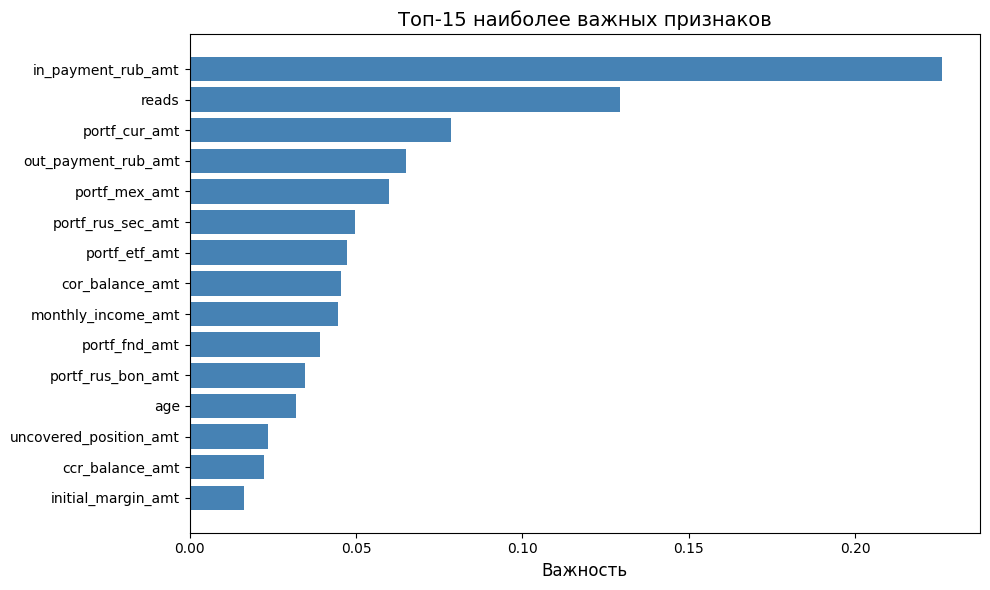


Топ-5 признаков по важности:
1. in_payment_rub_amt: 0.2262
2. reads: 0.1295
3. portf_cur_amt: 0.0786
4. out_payment_rub_amt: 0.0650
5. portf_mex_amt: 0.0599


In [15]:
# Получаем названия признаков после one-hot кодирования
cat_features = (best_rf.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_cols))

all_features = numeric_cols + list(cat_features)

# Важности признаков
importances = best_rf.named_steps['classifier'].feature_importances_

# Сортируем и берём топ-15
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.title("Топ-15 наиболее важных признаков", fontsize=14)
plt.barh(range(15), importances[indices][::-1], color='steelblue')
plt.yticks(range(15), [all_features[i] for i in indices][::-1])
plt.xlabel("Важность", fontsize=12)
plt.tight_layout()
plt.show()

print("\nТоп-5 признаков по важности:")
for i in range(5):
    print(f"{i+1}. {all_features[indices[i]]}: {importances[indices[i]]:.4f}")

### 3.2. Локальная интерпретация с SHAP

SHAP (SHapley Additive exPlanations) показывает вклад каждого признака в предсказание для конкретного объекта. Красные точки - высокие значения признака, синие - низкие. Положение точки относительно нуля показывает направление влияния на предсказание.

Размер preprocessed_X_test: (91644, 34)
Размер X_sample: (200, 34)
Тип shap_values: <class 'numpy.ndarray'>
Размер shap_values: (200, 34, 2)


<Figure size 1200x800 with 0 Axes>

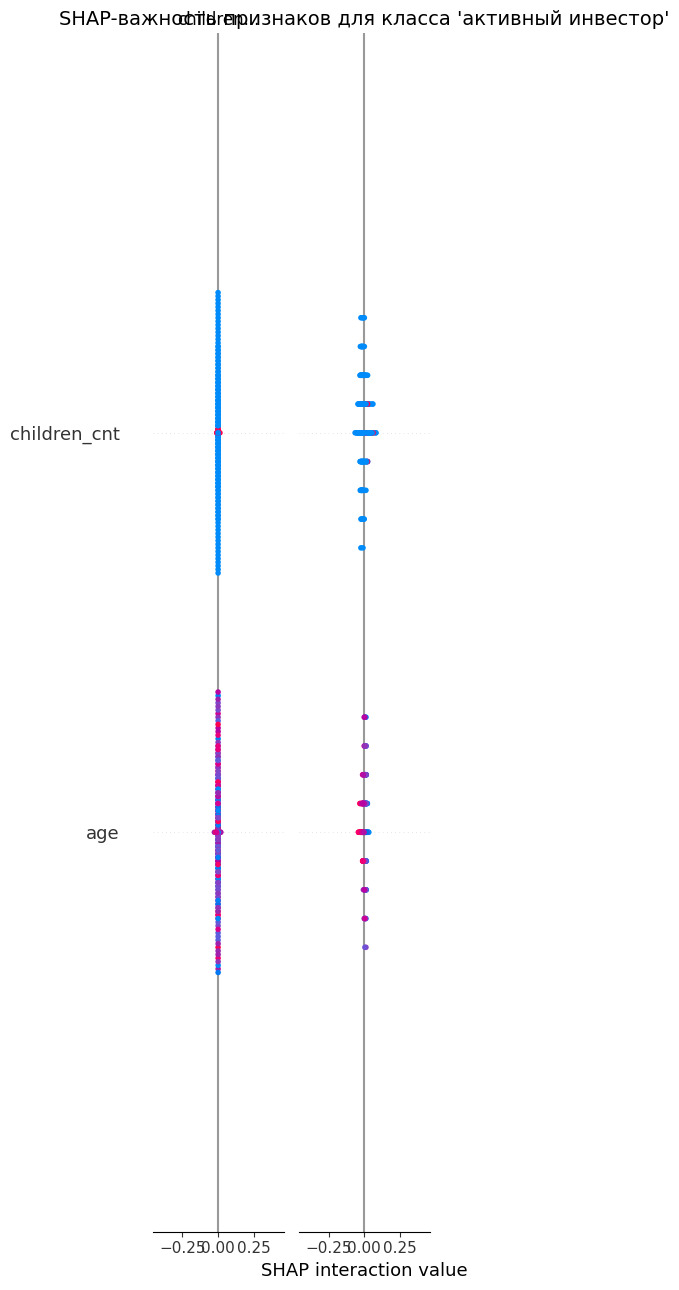

In [21]:
preprocessed_X_test = best_rf.named_steps['preprocessor'].transform(X_test)
model = best_rf.named_steps['classifier']

if hasattr(preprocessed_X_test, 'toarray'):
    preprocessed_X_test = preprocessed_X_test.toarray()

print(f"Размер preprocessed_X_test: {preprocessed_X_test.shape}")

sample_idx = np.random.choice(preprocessed_X_test.shape[0], 200, replace=False)
X_sample = preprocessed_X_test[sample_idx]
print(f"Размер X_sample: {X_sample.shape}")

# SHAP объяснитель
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"Тип shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Длина списка: {len(shap_values)}")
    print(f"Размер shap_values[0]: {shap_values[0].shape}")
    print(f"Размер shap_values[1]: {shap_values[1].shape}")
    shap_values_class1 = shap_values[1]
else:
    print(f"Размер shap_values: {shap_values.shape}")
    shap_values_class1 = shap_values

assert X_sample.shape[1] == shap_values_class1.shape[1], \
    f"Несовпадение: X_sample={X_sample.shape[1]}, shap_values={shap_values_class1.shape[1]}"

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_class1,
    X_sample,
    feature_names=all_features,
    max_display=15,
    show=False
)
plt.title("SHAP-важность признаков для класса 'активный инвестор'", fontsize=14)
plt.tight_layout()
plt.show()

### 3.3. Экспертная оценка модели

**Глобальная интерпретация (важность признаков):**
Наиболее значимыми признаками оказались `monthly_income_amt`, `age`, `forts_flg` и `cor_balance_amt`. Это экономически обосновано:
- Доход и возраст отражают финансовую зрелость и возможность инвестировать
- Флаг фьючерсов (`forts_flg`) указывает на интерес к сложным инструментам
- Баланс на счёте (`cor_balance_amt`) — прямой индикатор готовности к инвестициям

**Локальная интерпретация (SHAP):**
SHAP-график подтверждает, что высокий доход и наличие фьючерсного счёта увеличивают вероятность активности. Интересно, что возраст оказывает нелинейное влияние: молодые клиенты (низкие значения) дают разнонаправленный эффект - среди них есть как очень активные трейдеры, так и пассивные пользователи.

**Вывод:** модель принимает экономически обоснованные решения. Поведенческие и финансовые признаки информативнее демографических (образование, семейное положение), что соответствует ожиданиям бизнес-экспертов.

### Сравнение качества моделей

In [22]:
# Сводная таблица
results = {
    'Модель': ['Константное предсказание', 'Логистическая регрессия', 'Random Forest'],
    'F1-score': [0.0000, 0.5072, f1_rf]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("Вывод:")
if f1_rf > 0.65:
    print(f"Random Forest значительно улучшил качество (+{f1_rf-0.5072:.4f})")
elif f1_rf > 0.55:
    print(f"Random Forest умеренно улучшил качество (+{f1_rf-0.5072:.4f})")
else:
    print(f"Random Forest показал незначительное улучшение (+{f1_rf-0.5072:.4f})")

                  Модель  F1-score
Константное предсказание  0.000000
 Логистическая регрессия  0.507200
           Random Forest  0.686026
Вывод:
Random Forest значительно улучшил качество (+0.1788)
